Павлусенко Ангеліна КН-42-15
Мета: Ознайомитися з основами класифікації при інтелектуальному аналізі даних на прикладі реального історичного набору даних Titanic.
Навчитись будувати класифікатор на основі дерев рішень (Decision Tree), виконувати попередню обробку даних, навчати модель, оцінювати якість класифікації за допомогою стандартних метрик та інтерпретувати отримані результати.

In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv("train.csv")
df.head()
df.info()
df.isnull().sum()
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop(columns=['Cabin'])
df['Sex'] = df['Sex'].map({ 'male': 0,
    'female': 1})
df['Embarked'] = df['Embarked'].map({'S': 0,
    'C': 1,
    'Q': 2})
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,1
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,0


In [5]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Було завантажено датасет Titanic та проведено попередню обробку даних. Було виявлено та оброблено пропущені значення у колонках Age та Embarked, а колонку Cabin видалено через велику кількість відсутніх даних. Також категоріальні ознаки Sex та Embarked були перетворені у числовий формат для подальшого використання у моделі класифікації.

In [6]:
from sklearn.model_selection import train_test_split

X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X,y,
    test_size=0.2,
    random_state=42)

print("Розмір навчальної вибірки X_train:", X_train.shape)
print("Розмір тестової вибірки X_test:", X_test.shape)

print("Розмір навчальної вибірки y_train:", y_train.shape)
print("Розмір тестової вибірки y_test:", y_test.shape)

Розмір навчальної вибірки X_train: (712, 7)
Розмір тестової вибірки X_test: (179, 7)
Розмір навчальної вибірки y_train: (712,)
Розмір тестової вибірки y_test: (179,)


Було поділено на навчальну та тестову вибірки за допомогою функції train_test_split(). Навчальна вибірка використовується для навчання моделі, а тестова — для перевірки якості її роботи на нових даних. Успішно отримано розміри обох вибірок.

In [7]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=4,
    random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [11]:
print("Глибина дерева:", model.get_depth())
print("Кількість вузлів:", model.tree_.node_count)
print("Перші прогнози моделі:")
print(y_pred[:10])

Глибина дерева: 4
Кількість вузлів: 29
Перші прогнози моделі:
[0 0 0 1 1 1 1 0 1 1]


Побудовано та навчено модель класифікації на основі дерева рішень. Після навчання моделі було отримано прогнозування для тестової вибірки. Також було проаналізовано структуру дерева, зокрема його глибину та кількість вузлів, що дозволяє оцінити складність моделі.

In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report)

import matplotlib.pyplot as plt
import seaborn as sns

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.7988826815642458
Precision: 0.8392857142857143
Recall: 0.6351351351351351
F1-score: 0.7230769230769231


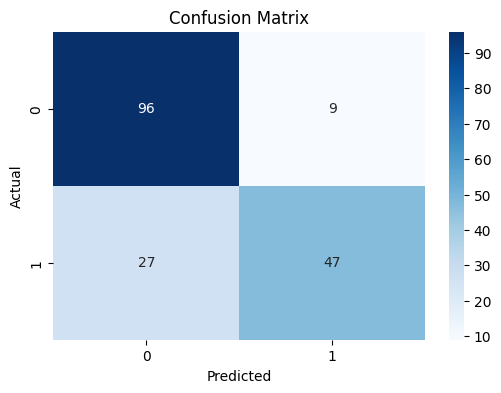

In [14]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm,
    annot=True,
    fmt='d',
    cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [15]:
print(classification_report(y_test, y_pred))
print(df['Survived'].value_counts())

              precision    recall  f1-score   support

           0       0.78      0.91      0.84       105
           1       0.84      0.64      0.72        74

    accuracy                           0.80       179
   macro avg       0.81      0.77      0.78       179
weighted avg       0.80      0.80      0.79       179

Survived
0    549
1    342
Name: count, dtype: int64


Оцінено якість моделі класифікації за допомогою основних метрик: Accuracy, Precision, Recall та F1-score. Також було побудовано confusion matrix і отримано детальний звіт classification_report.
Аналіз показав, що класи у наборі даних Titanic є частково незбалансованими, оскільки кількість пасажирів, які не вижили, більша за кількість тих, хто вижив. Тому для цього завдання більш інформативними є метрики Precision, Recall та F1-score, оскільки вони краще характеризують якість класифікації для кожного класу окремо.

In [16]:
from sklearn import tree

importance = pd.DataFrame({'Feature': X.columns,
    'Importance': model.feature_importances_})
importance = importance.sort_values(by='Importance',
    ascending=False)

print(importance)

    Feature  Importance
1       Sex    0.579608
0    Pclass    0.200498
5      Fare    0.081064
2       Age    0.078872
3     SibSp    0.046059
6  Embarked    0.013900
4     Parch    0.000000


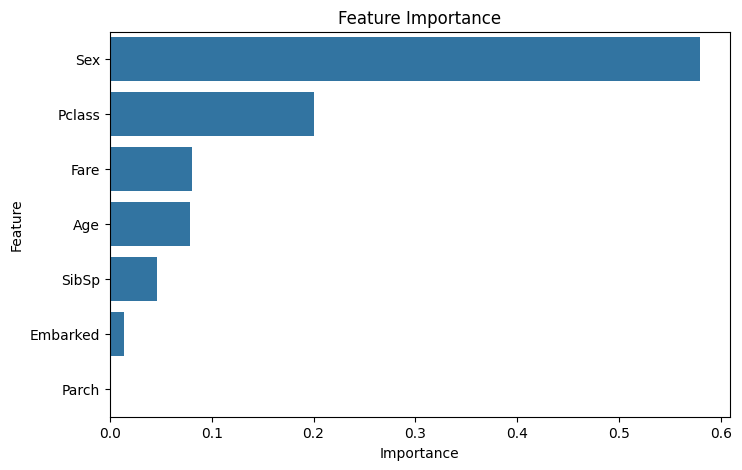

In [17]:
plt.figure(figsize=(8, 5))

sns.barplot( x='Importance',
    y='Feature',
    data=importance)

plt.title("Feature Importance")
plt.show()

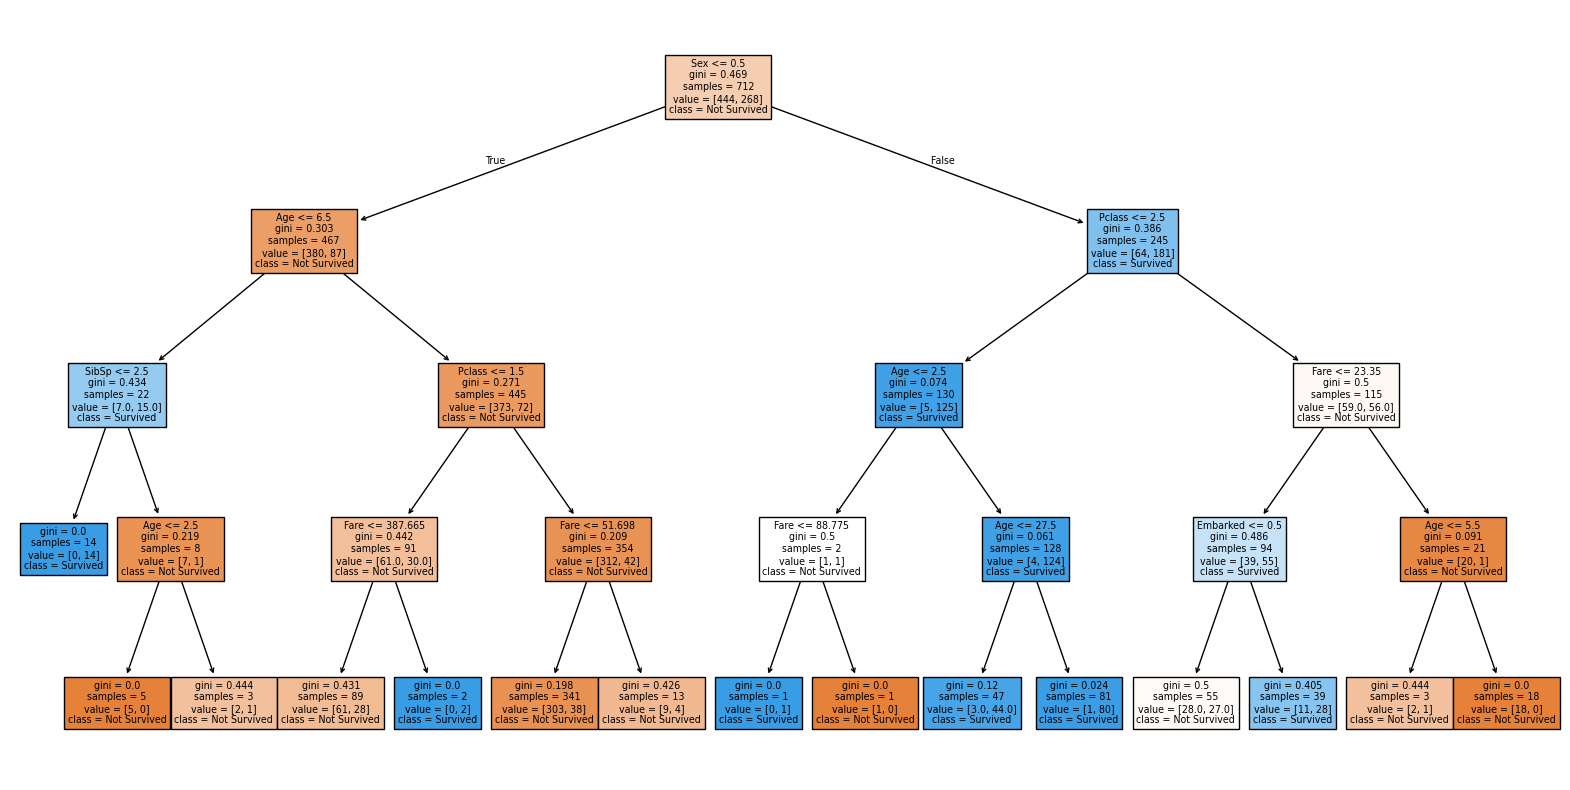

In [18]:
plt.figure(figsize=(20, 10))
tree.plot_tree(    model,
    feature_names=X.columns,
    class_names=['Not Survived', 'Survived'],
    filled=True)

plt.show()

Проаналізовано важливість ознак, отриману з моделі дерева рішень. Найбільший вплив на ймовірність виживання пасажирів мали стать, клас каюти та вік. Також було побудовано графік важливості ознак і візуалізовано дерево рішень, що дозволило краще зрозуміти процес прийняття рішень моделлю.